# ╔════════════════════════════════════════════════════════════╗
# ║ 🍄 きのこ　🍄
# ╚════════════════════════════════════════════════════════════╝


# ===================== IMPORTS ======================

In [159]:
# ═════════════════════ LOAD ═════════════════════
from pathlib import Path
import os

# ═════════════════════ SECTION ═════════════════════
import pandas as pd
import numpy as np

# ═════════════════════ VISUALIZATION TOOLS ═════════════════════
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# ═════════════════════ CNN ═════════════════════
from tensorflow.keras import Sequential, layers, optimizers, callbacks, regularizers, Model
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.metrics import AUC
import tensorflow as tf

# ═════════════════════ OTHER ═════════════════════
from datetime import datetime
from tensorflow.keras.preprocessing.image import load_img, save_img, img_to_array

# ===================== PREPROCESSING ======================

In [45]:
# # ░░░░░░░░░░░░░░ DATA AUGMENTATION (edible) ░░░░░░░░░░░░░░

# def augment_edible(edible_dir="data/image_dataset/edible"):
#     paths = list(Path(edible_dir).rglob("*.png"))

#     for p in paths:
#         save_img(str(p.parent / f"aug_{p.name}"), np.fliplr(img_to_array(load_img(p))))

# augment_edible()

# DO NOT RUN

In [160]:
print(f"🍄 Edible: {len(list(Path('../data/image_dataset/edible').rglob('*.jpg')) + list(Path('../data/image_dataset/edible').rglob('*.png')))}")
print(f"☠️ Poisonous: {len(list(Path('../data/image_dataset/poisonous').rglob('*.jpg')) + list(Path('../data/image_dataset/poisonous').rglob('*.png')))}")

🍄 Edible: 4950
☠️ Poisonous: 5497


# =====================[■■■■■■■■■□] 90% LOADING ======================


In [161]:
paths = list(Path("../data/image_dataset/").rglob("*.png"))
df = pd.DataFrame({
    "path": paths,
    "label": [p.parent.name for p in paths]
})

# ===================== CONFIGURATION ======================

In [162]:
# ░░ 💾 Save best model ░░
timestamp = datetime.now().strftime("%d%m%Y_%H%M%S")
os.makedirs("../models/images/baseline/keras_models", exist_ok=True)
MODEL_1 = "../models/images/baseline/keras_models/model_1.keras"
MODEL_2 = "../models/images/baseline/keras_models/augmented_1.keras"
MODEL_3 = "../models/images/baseline/keras_models/augmented_2.keras"


# ░░ 🏋 Training history logs ░░
os.makedirs("../models/images/baseline/logs", exist_ok=True)
csv_logger_1 = CSVLogger(f"../models/images/baseline/logs/baseline_history_{timestamp}.csv")
csv_logger_2 = CSVLogger(f"../models/images/baseline/logs/augmented_history_{timestamp}.csv")
csv_logger_3 = CSVLogger(f"../models/images/baseline/logs/augmented_2_history_{timestamp}.csv")

# ===================== MODEL BASELINE ======================

In [163]:
def initialize_baseline_model():
    baseline = Sequential([
        layers.Input(shape=(128, 128,3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(512, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])

    return baseline


In [164]:
baseline = initialize_baseline_model()
baseline.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_18 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_72 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_73 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_74 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 16, 16, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,881,761 (18.62 MB)

 Trainable params: 4,880,289 (18.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [165]:
# ░░░░░░░░░░░░░░ Compilation ░░░░░░░░░░░░░░

def compile_baseline_model(baseline):
    adam = optimizers.Adam(learning_rate = 1e-4)
    baseline.compile(
        loss = "binary_crossentropy",
        optimizer=adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )

    return baseline

In [ ]:
dataset_dir = os.path.abspath("../data/image_dataset")

# ░░░░░░░░░░░░░░ Define data ░░░░░░░░░░░░░░
batch_size = 32

# We define a first one for the train data
train_ds = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "training",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size),


# We define a second one for the test data
val_ds = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "validation",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)

Found 10447 files belonging to 2 classes.
Using 8358 files for training.
Found 10447 files belonging to 2 classes.
Using 2089 files for validation.


In [169]:
# ░░░░░░░░░░░░░░ Inspect binary classification configuration ░░░░░░░░░░░░░░
class_names = train_ds.class_names
print(class_names)

AttributeError: 'tuple' object has no attribute 'class_names'

In [71]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
baseline = initialize_baseline_model()
baseline = compile_baseline_model(baseline)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_1,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=3,
                                        verbose=1,
                                        min_lr=1e-6)

history = baseline.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint, csv_logger_1],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 42s 155ms/step - accuracy: 0.5816 - auc: 0.6166 - loss: 0.7255 - precision: 0.5954 - recall: 0.6466 - val_accuracy: 0.4806 - val_auc: 0.4672 - val_loss: 1.8425 - val_precision: 1.0000 - val_recall: 9.2081e-04 - learning_rate: 1.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 42s 160ms/step - accuracy: 0.6157 - auc: 0.6688 - loss: 0.6449 - precision: 0.6291 - recall: 0.6624 - val_accuracy: 0.6204 - val_auc: 0.6783 - val_loss: 0.6464 - val_precision: 0.6722 - val_recall: 0.5267 - learning_rate: 1.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 43s 164ms/step - accuracy: 0.6500 - auc: 0.7151 - loss: 0.6143 - precision: 0.6634 - recall: 0.6837 - val_accuracy: 0.6371 - val_auc: 0.6978 - val_loss: 0.6362 - val_precision: 0.6316 - val_recall: 0.7247 - learning_rate: 1.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 43s 164ms/step - accuracy: 0.6788 - auc: 0.7546 - loss: 0.5807 - precision: 0.6960 - recall: 0.6949 - val_accuracy: 0.6405 - val_auc:

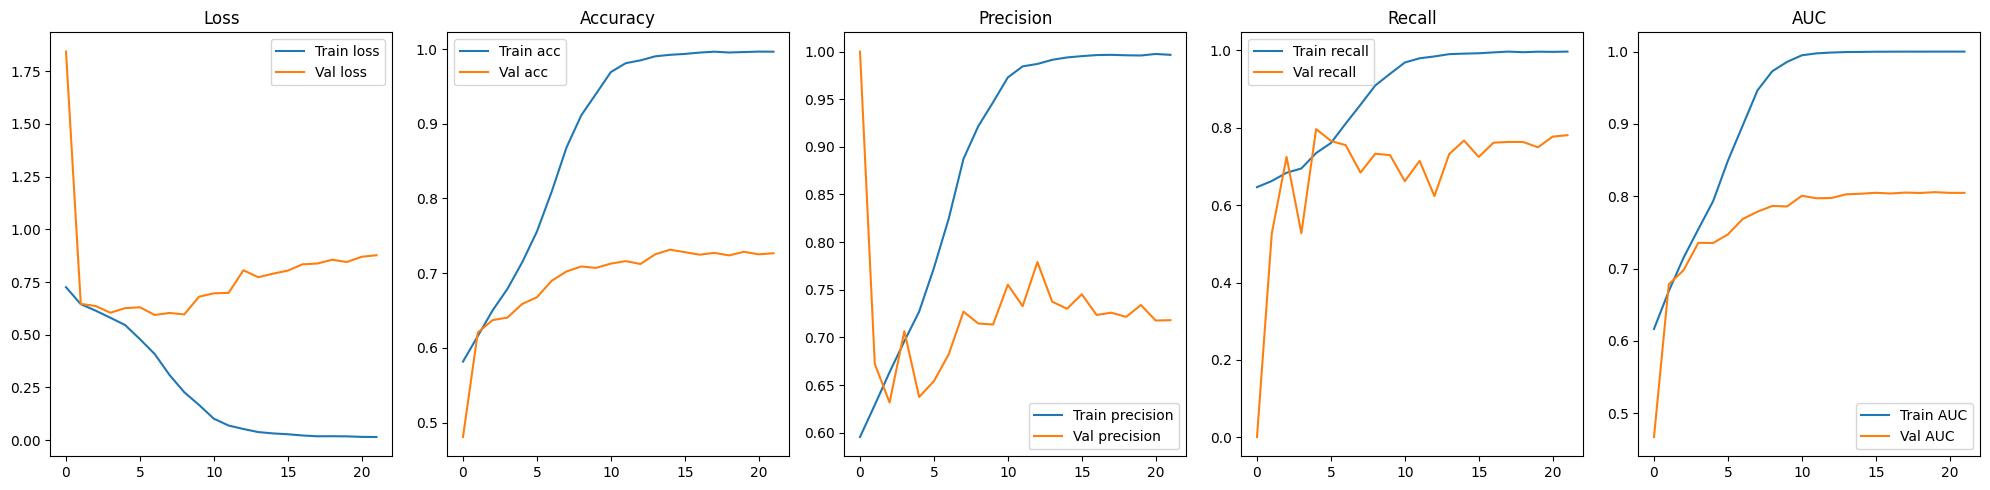

In [72]:
def plot_history(history):
    fig, ax = plt.subplots(1, 5, figsize=(20, 5))

    # ░░ Row 1 : Train & Val Loss ░░
    ax[0].set_title('Loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Val loss")

    # ░░ Row 1 : Train & Val Accuracy ░░
    ax[1].set_title('Accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Val acc")

    # ░░ Row 1 : Train & Val Precision ░░
    ax[2].set_title('Precision')
    ax[2].plot(history.epoch, history.history["precision"], label="Train precision")
    ax[2].plot(history.epoch, history.history["val_precision"], label="Val precision")

    # ░░ Row 1 : Train & Val Recall ░░
    ax[3].set_title('Recall')
    ax[3].plot(history.epoch, history.history["recall"], label="Train recall")
    ax[3].plot(history.epoch, history.history["val_recall"], label="Val recall")

    # ░░ Row 1 : Train & Val AUC ░░
    ax[4].set_title('AUC')
    ax[4].plot(history.epoch, history.history["auc"], label="Train AUC")
    ax[4].plot(history.epoch, history.history["val_auc"], label="Val AUC")

    for a in ax:
        a.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [73]:
# Loss, Accuracy, Precision, Recall, AUC
baseline.evaluate(val_ds)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6898 - auc: 0.7686 - loss: 0.5937 - precision: 0.6822 - recall: 0.7551


[0.5937393307685852,
 0.6898037195205688,
 0.682196319103241,
 0.7550644278526306,
 0.768589198589325]

# ===================== MODEL BASELINE + DATA AUGMENTATION ======================

In [74]:
def initialize_augmented_model():
    augmented = Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Rescaling(1./255),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(256, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        layers.Dropout(0.4),

        layers.Dense(1, activation="sigmoid")
    ])
    return augmented

In [75]:
augmented = initialize_augmented_model()
augmented.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_12 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,033 (1.62 MB)

 Trainable params: 423,073 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [76]:
def compile_augmented_model(augmented):
    adam = optimizers.Adam(learning_rate = 1e-4)

    augmented.compile(
        loss = "binary_crossentropy",
        optimizer = adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )
    return augmented

In [77]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
augmented = initialize_augmented_model()
augmented = compile_augmented_model(augmented)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_2,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=5,
                                        verbose=1,
                                        min_lr=1e-6)
history_2 = augmented.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint,csv_logger_2],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.5901 - auc: 0.6193 - loss: 0.6950 - precision: 0.6026 - recall: 0.6556 - val_accuracy: 0.4404 - val_auc: 0.4318 - val_loss: 0.7540 - val_precision: 0.3630 - val_recall: 0.1013 - learning_rate: 1.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 128ms/step - accuracy: 0.6103 - auc: 0.6608 - loss: 0.6554 - precision: 0.6182 - recall: 0.6842 - val_accuracy: 0.5720 - val_auc: 0.5865 - val_loss: 0.6955 - val_precision: 0.5646 - val_recall: 0.7726 - learning_rate: 1.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 130ms/step - accuracy: 0.6304 - auc: 0.6843 - loss: 0.6401 - precision: 0.6379 - recall: 0.6930 - val_accuracy: 0.6166 - val_auc: 0.6929 - val_loss: 0.6401 - val_precision: 0.6004 - val_recall: 0.7845 - learning_rate: 1.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.6390 - auc: 0.6898 - loss: 0.6341 - precision: 0.6467 - recall: 0.6967 - val_accuracy: 0.6266 - val_auc: 0.6

# ===================== MODEL BASELINE + DATA AUGMENTATION version 2 ======================

In [78]:
def initialize_augmented_2_model():
    augmented_2 = Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Rescaling(1./255),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),

        layers.Conv2D(32, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(256, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])
    return augmented_2

In [79]:
augmented_2 = initialize_augmented_2_model()
augmented_2.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 4,586,177 (17.49 MB)

 Trainable params: 4,584,705 (17.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [89]:
def compile_augmented_2_model(augmented_2):
    adam = optimizers.Adam(learning_rate = 1e-3)

    augmented_2.compile(
        loss = "binary_crossentropy",
        optimizer = adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )
    return augmented_2

In [97]:

%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
augmented_2 = initialize_augmented_2_model()
augmented_2 = compile_augmented_2_model(augmented_2)

ES = EarlyStopping(
    monitor="val_loss",   # explicit is better
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_3,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=5,
                                        cooldown=2,   # <-- wait 2 epochs after reducing before monitoring again
                                        verbose=1,
                                        min_lr=1e-6)
history_3 = augmented_2.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint,csv_logger_3],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.5778 - auc: 0.6175 - loss: 0.7757 - precision: 0.5949 - recall: 0.6266 - val_accuracy: 0.4801 - val_auc: 0.5320 - val_loss: 1.3343 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step - accuracy: 0.6374 - auc: 0.6851 - loss: 0.6796 - precision: 0.6493 - recall: 0.6803 - val_accuracy: 0.5606 - val_auc: 0.6455 - val_loss: 0.7910 - val_precision: 0.7320 - val_recall: 0.2440 - learning_rate: 0.0010
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.6448 - auc: 0.6982 - loss: 0.6647 - precision: 0.6555 - recall: 0.6890 - val_accuracy: 0.6285 - val_auc: 0.7050 - val_loss: 0.6721 - val_precision: 0.6042 - val_recall: 0.8278 - learning_rate: 0.0010
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.6625 - auc: 0.7209 - loss: 0.6452 - precision: 0.6732 - recall: 0.7005 - val_accuracy: 0.5955 - val_auc: 0.7073 

In [100]:
def plot_history(history, history_2, history_3):
    fig, ax = plt.subplots(6, 1, figsize=(12, 24))

    # ░░ Row 1 : Train loss ░░
    ax[0].set_title('Train Loss Comparison')
    ax[0].plot(history.epoch, history.history["loss"], label="Baseline")
    ax[0].plot(history_2.epoch, history_2.history["loss"], label="Augmented", color="red")
    ax[0].plot(history_3.epoch, history_3.history["loss"], label="Augmented_2", color="green")
    ax[0].legend()

    # ░░ Row 2 : Val loss ░░
    ax[1].set_title('Validation Loss Comparison')
    ax[1].plot(history.epoch, history.history["val_loss"], label="Baseline")
    ax[1].plot(history_2.epoch, history_2.history["val_loss"], label="Augmented", color="red")
    ax[1].plot(history_3.epoch, history_3.history["val_loss"], label="Augmented_2", color="green")
    ax[1].legend()

    # ░░ Row 3 : Train Accuracy ░░
    ax[2].set_title('Train Accuracy Comparison')
    ax[2].plot(history.epoch, history.history["accuracy"], label="Baseline")
    ax[2].plot(history_2.epoch, history_2.history["accuracy"], label="Augmented", color="red")
    ax[2].plot(history_3.epoch, history_3.history["accuracy"], label="Augmented_2", color="green")
    ax[2].legend()

    # ░░ Row 4 : Val Accuracy ░░
    ax[3].set_title('Validation Accuracy Comparison')
    ax[3].plot(history.epoch, history.history["val_accuracy"], label="Baseline")
    ax[3].plot(history_2.epoch, history_2.history["val_accuracy"], label="Augmented", color="red")
    ax[3].plot(history_3.epoch, history_3.history["val_accuracy"], label="Augmented_2", color="green")
    ax[3].legend()

    # ░░ Row 5 : Train AUC ░░
    ax[4].set_title('Train AUC Comparison')
    ax[4].plot(history.epoch, history.history["auc"], label="Baseline")
    ax[4].plot(history_2.epoch, history_2.history["auc"], label="Augmented", color="red")
    ax[4].plot(history_3.epoch, history_3.history["auc"], label="Augmented_2", color="green")
    ax[4].legend()

    # ░░ Row 6 : Val AUC ░░
    ax[5].set_title('Validation AUC Comparison')
    ax[5].plot(history.epoch, history.history["val_auc"], label="Baseline")
    ax[5].plot(history_2.epoch, history_2.history["val_auc"], label="Augmented", color="red")
    ax[5].plot(history_3.epoch, history_3.history["val_auc"], label="Augmented_2", color="green")
    ax[5].legend()

    plt.tight_layout()
    plt.show()

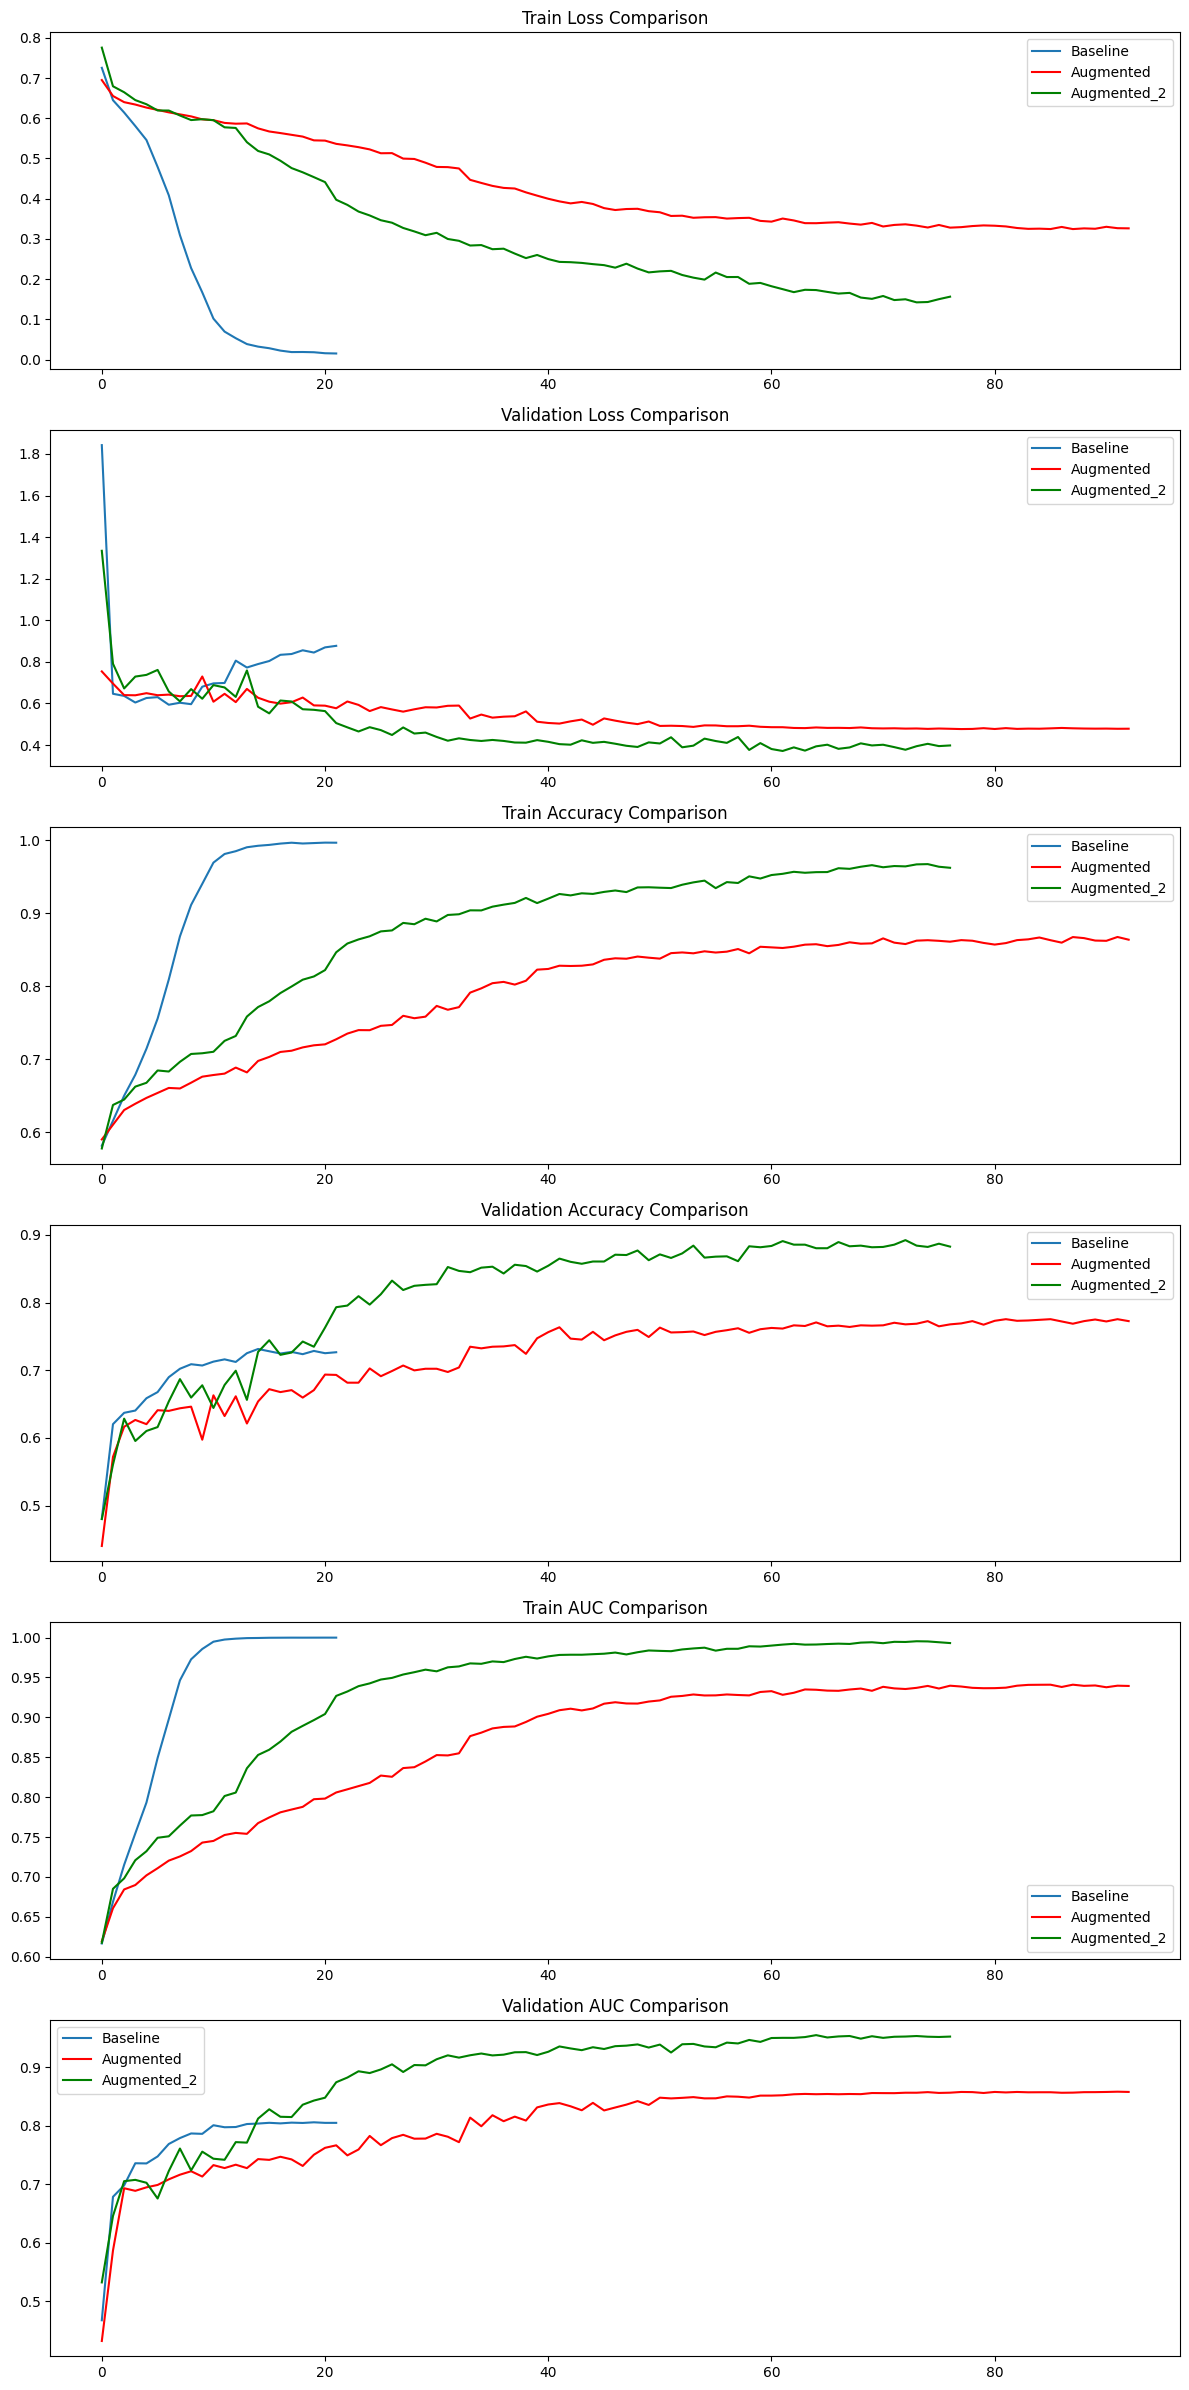

In [101]:
plot_history(history, history_2, history_3)

In [107]:
display(baseline.evaluate(val_ds), augmented.evaluate(val_ds), augmented_2.evaluate(val_ds))

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6898 - auc: 0.7686 - loss: 0.5937 - precision: 0.6822 - recall: 0.7551
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7707 - auc: 0.8574 - loss: 0.4772 - precision: 0.7787 - recall: 0.7808
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8909 - auc: 0.9500 - loss: 0.3713 - precision: 0.9248 - recall: 0.8600


[0.5937392711639404,
 0.6898037195205688,
 0.682196319103241,
 0.7550644278526306,
 0.768589198589325]

[0.47720634937286377,
 0.7707036733627319,
 0.7786960601806641,
 0.7808471322059631,
 0.8574392199516296]

[0.37127169966697693,
 0.8908568620681763,
 0.9247524738311768,
 0.8600368499755859,
 0.9500489830970764]

In [158]:
# ░░ 🔮 Prediction ░░

# # preds_base = probability that the image belongs to class 1
# preds_base = baseline.predict(val_ds, verbose=0)

# # preds_aug = probability that the image belongs to class 1
# preds_augm = augmented.predict(val_ds, verbose=0)

# # preds_aug_2 = probability that the image belongs to class 1
# preds_augm_2 = augmented_2.predict(val_ds, verbose=0)

# df_prediction = pd.DataFrame({
#     "Baseline": preds_base.flatten(),
#     "Augmented": preds_augm.flatten(),
#     "Augmented_2": preds_augm_2.flatten(),
# })

# display(df_prediction.head(10))

all_images, all_labels = [], []

for images, labels in val_ds:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0).flatten()


# preds_base = probability that the image belongs to class 1
preds_base = baseline.predict(all_images, verbose=0)

# preds_aug = probability that the image belongs to class 1
preds_augm = augmented.predict(all_images, verbose=0)

# preds_aug_2 = probability that the image belongs to class 1
preds_augm_2 = augmented_2.predict(all_images, verbose=0)


df_prediction = pd.DataFrame({
    "Baseline_proba":    preds_base.flatten(),
    "Augmented_proba":   preds_augm.flatten(),
    "Augmented_2_proba": preds_augm_2.flatten(),
    "true_label":        all_labels,
})

display(df_prediction.head(10))


,Baseline_proba,Augmented_proba,Augmented_2_proba,true_label
0,0.649633,0.437717,0.010119,0.0
1,0.222695,0.244489,0.338807,0.0
2,0.842401,0.497885,0.991998,1.0
3,0.711467,0.929949,0.479210,0.0
4,0.466721,0.508739,0.955164,1.0
5,0.307717,0.876724,0.014877,0.0
6,0.902394,0.921386,0.992161,1.0
7,0.833184,0.717153,0.729980,1.0
8,0.628867,0.544828,0.885436,1.0
9,0.382711,0.318754,0.872646,1.0


In [141]:
# ░░ 🔮 Prediction Label 1 ░░
# if > 0.5 → 1 else → 0

# Convert baseline predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels = (preds_base > 0.5).astype(int)

# Convert augmented baseline predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels_2 = (preds_augm > 0.5).astype(int)

# Convert augmented baseline 2 predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels_3 = (preds_augm_2 > 0.5).astype(int)

display(pred_labels, pred_labels_2, pred_labels_3)

array([[0],
       [0],
       [1],
       ...,
       [1],
       [1],
       [1]], shape=(2089, 1))

array([[0],
       [0],
       [0],
       ...,
       [1],
       [1],
       [1]], shape=(2089, 1))

array([[0],
       [0],
       [1],
       ...,
       [1],
       [1],
       [1]], shape=(2089, 1))

In [157]:
# ░░ 🎨  Let's have something prettier ░░
true_labels = np.concatenate([y for x, y in val_ds], axis=0)

df_proba_results = pd.DataFrame({
    "Baseline_proba": preds_base.flatten(),
    "Augmented_proba": preds_augm.flatten(),
    "Augmented_2_proba": preds_augm_2.flatten(),
    "true_label": true_labels.flatten(),
})

class_map = dict(enumerate(class_names))

df_proba_results["Baseline_label"] = (df_proba_results["Baseline_proba"] > 0.5).astype(int)
df_proba_results["Augmented_label"] = (df_proba_results["Augmented_proba"] > 0.5).astype(int)
df_proba_results["Augmented_2_label"] = (df_proba_results["Augmented_2_proba"] > 0.5).astype(int)
df_proba_results["Baseline_class"] = (df_proba_results["Baseline_label"].map(class_map))
df_proba_results["Augmented_class"] = (df_proba_results["Augmented_label"].map(class_map))
df_proba_results["Augmented_2_class"] = (df_proba_results["Augmented_2_label"].map(class_map))

df_proba_results.to_csv(f"../models/images/baseline/results/baselines_probability_{timestamp}.csv", index=False)

df_proba_results.head(20)

errors = df_proba_results[df_proba_results["Augmented_2_label"] != df_proba_results["true_label"]]
print(f"Taux erreur : {len(errors)/len(df_proba_results)*100:.1f}%")
print(f"Nombre erreurs : {len(errors)}/{len(df_proba_results)}")

# Distribution des erreurs
print("\nFaux positifs (prédit poisonous, vrai edible):",
      len(df_proba_results[(df_proba_results["Augmented_2_label"]==1) & (df_proba_results["true_label"]==0)]))
print("Faux négatifs (prédit edible, vrai poisonous):",
      len(df_proba_results[(df_proba_results["Augmented_2_label"]==0) & (df_proba_results["true_label"]==1)]))

Taux erreur : 48.6%
Nombre erreurs : 1016/2089

Faux positifs (prédit poisonous, vrai edible): 967
Faux négatifs (prédit edible, vrai poisonous): 49


In [113]:
# ░░ 💾 Save all results ░░
os.makedirs("results", exist_ok=True)
results = []

baseline_eval = baseline.evaluate(val_ds, return_dict=True)
augmented_eval = augmented.evaluate(val_ds, return_dict=True)
augmented_2_eval = augmented_2.evaluate(val_ds, return_dict=True)

results.append({
    "model": "🧱 baseline",
    **baseline_eval
})

results.append({
    "model": "💪 augmented",
    **augmented_eval
})

results.append({
    "model": "🦾 augmented_2",
    **augmented_2_eval
})

df_results = pd.DataFrame(results)
df_results.to_csv(f"../models/images/baseline/results/df_results_eval_{timestamp}.csv", index=False)

display(df_results)

66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6898 - auc: 0.7686 - loss: 0.5937 - precision: 0.6822 - recall: 0.7551
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7707 - auc: 0.8574 - loss: 0.4772 - precision: 0.7787 - recall: 0.7808
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8909 - auc: 0.9500 - loss: 0.3713 - precision: 0.9248 - recall: 0.8600


,model,accuracy,auc,loss,precision,recall
0,🧱 baseline,0.689804,0.768589,0.593739,0.682196,0.755064
1,💪 augmented,0.770704,0.857439,0.477206,0.778696,0.780847
2,🦾 augmented_2,0.890857,0.950049,0.371272,0.924752,0.860037


In [ ]:
df_proba_results = pd.DataFrame({
    "Augmented_2_proba": preds_augm_2.flatten(),
    "true_label": all_labels,
})

df_proba_results["Augmented_2_label"] = (df_proba_results["Augmented_2_proba"] > 0.5).astype(int)
df_proba_results["true_label_int"] = df_proba_results["true_label"].astype(int)

errors = df_proba_results[df_proba_results["Augmented_2_label"] != df_proba_results["true_label_int"]]
print(f"Taux erreur : {len(errors)/len(df_proba_results)*100:.1f}%")
print(f"Nombre erreurs : {len(errors)}/{len(df_proba_results)}")

# Distribution des erreurs
print("\nFaux positifs (prédit poisonous, vrai edible):",
      len(df_proba_results[(df_proba_results["Augmented_2_label"]==1) & (df_proba_results["true_label_int"]==0)]))
print("Faux négatifs (prédit edible, vrai poisonous):",
      len(df_proba_results[(df_proba_results["Augmented_2_label"]==0) & (df_proba_results["true_label_int"]==1)]))

Taux erreur : 4.1%
Nombre erreurs : 85/2089

Faux positifs (prédit poisonous, vrai edible): 0
Faux négatifs (prédit edible, vrai poisonous): 85
